# Day 05 – Phase 3  
# PCA vs. t-SNE vs. UMAP on Gene Expression RNA-Seq

**Goal:** Compare linear PCA with nonlinear dimensionality reduction methods t-SNE and UMAP.

This notebook performs:

1. Load Gene Expression Cancer RNA-Seq dataset  
2. Standardize gene features  
3. PCA 2D  
4. t-SNE 2D  
5. UMAP 2D  
6. Compare runtime and trustworthiness  
7. Compare direct UMAP with PCA(50) + UMAP  
8. Save figures and result tables  

```


In [2]:
%pip install umap-learn

Note: you may need to restart the kernel to use updated packages.


In [3]:
# ============================================================
# Day 05 - Phase 3
# PCA vs. t-SNE vs. UMAP
# Dataset: Gene Expression Cancer RNA-Seq
# ============================================================

import os
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.manifold import TSNE, trustworthiness

warnings.filterwarnings("ignore")

# UMAP is optional but required for the full phase 3 task.
try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False

print("UMAP available:", UMAP_AVAILABLE)
if not UMAP_AVAILABLE:
    print("Install with: pip install umap-learn")

UMAP available: True


In [4]:
# ============================================================
# Folder paths
# ============================================================

DAY04_DIR = r"C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_04_Outlier_Anomaly"
AUFGABE_DIR = os.path.dirname(DAY04_DIR)

BASE_DIR = os.path.join(AUFGABE_DIR, "Tag_05_PCA_Dimensionsreduktion")

DATA_DIR = os.path.join(BASE_DIR, "data")
GENE_DIR = os.path.join(DATA_DIR, "gene_expression")

OUTPUT_DIR = os.path.join(BASE_DIR, "output")
FIGURES_DIR = os.path.join(OUTPUT_DIR, "figures")
TABLES_DIR = os.path.join(OUTPUT_DIR, "tables")
MODELS_DIR = os.path.join(OUTPUT_DIR, "models")
REPORTS_DIR = os.path.join(OUTPUT_DIR, "reports")
NOTEBOOKS_DIR = os.path.join(BASE_DIR, "notebooks")

PHASE3_FIGURES_DIR = os.path.join(FIGURES_DIR, "phase3")
PHASE3_TABLES_DIR = os.path.join(TABLES_DIR, "phase3")

folders = [
    BASE_DIR, DATA_DIR, GENE_DIR, OUTPUT_DIR, FIGURES_DIR, TABLES_DIR,
    MODELS_DIR, REPORTS_DIR, NOTEBOOKS_DIR, PHASE3_FIGURES_DIR, PHASE3_TABLES_DIR
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("BASE_DIR:", BASE_DIR)
print("GENE_DIR:", GENE_DIR)
print("PHASE3_FIGURES_DIR:", PHASE3_FIGURES_DIR)
print("PHASE3_TABLES_DIR:", PHASE3_TABLES_DIR)

BASE_DIR: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_05_PCA_Dimensionsreduktion
GENE_DIR: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_05_PCA_Dimensionsreduktion\data\gene_expression
PHASE3_FIGURES_DIR: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_05_PCA_Dimensionsreduktion\output\figures\phase3
PHASE3_TABLES_DIR: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_05_PCA_Dimensionsreduktion\output\tables\phase3


In [5]:
# ============================================================
# Load Gene Expression Dataset - Robust Version
# Looks for data.csv and labels.csv automatically
# ============================================================

expected_data_file = os.path.join(GENE_DIR, "data.csv")
expected_labels_file = os.path.join(GENE_DIR, "labels.csv")

data_file = None
labels_file = None

if os.path.exists(expected_data_file):
    data_file = expected_data_file

if os.path.exists(expected_labels_file):
    labels_file = expected_labels_file

if data_file is None or labels_file is None:
    print("Expected files not found in:")
    print(GENE_DIR)
    print("\nSearching inside BASE_DIR...")

    for root, dirs, files in os.walk(BASE_DIR):
        for file in files:
            lower_file = file.lower()

            if lower_file == "data.csv":
                data_file = os.path.join(root, file)

            if lower_file == "labels.csv":
                labels_file = os.path.join(root, file)

print("\nDetected files:")
print("data_file  :", data_file)
print("labels_file:", labels_file)

if data_file is None or labels_file is None:
    print("\n❌ data.csv or labels.csv was not found.")
    print("Please download/extract the Kaggle dataset and place both files here:")
    print(GENE_DIR)
    raise FileNotFoundError("Missing data.csv and/or labels.csv")

data_raw = pd.read_csv(data_file)
labels_raw = pd.read_csv(labels_file)

print("\n✅ Files loaded successfully.")
print("data_raw shape:", data_raw.shape)
print("labels_raw shape:", labels_raw.shape)

display(data_raw.head())
display(labels_raw.head())


Detected files:
data_file  : C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_05_PCA_Dimensionsreduktion\data\gene_expression\data.csv
labels_file: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_05_PCA_Dimensionsreduktion\data\gene_expression\labels.csv

✅ Files loaded successfully.
data_raw shape: (801, 20532)
labels_raw shape: (801, 2)


,Unnamed: 0,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,...,gene_20521,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530
0,sample_0,0.0,2.017209,3.265527,5.478487,10.431999,0.0,7.175175,0.591871,0.0,...,4.926711,8.210257,9.723516,7.220030,9.119813,12.003135,9.650743,8.921326,5.286759,0.0
1,sample_1,0.0,0.592732,1.588421,7.586157,9.623011,0.0,6.816049,0.000000,0.0,...,4.593372,7.323865,9.740931,6.256586,8.381612,12.674552,10.517059,9.397854,2.094168,0.0
2,sample_2,0.0,3.511759,4.327199,6.881787,9.870730,0.0,6.972130,0.452595,0.0,...,5.125213,8.127123,10.908640,5.401607,9.911597,9.045255,9.788359,10.090470,1.683023,0.0
3,sample_3,0.0,3.663618,4.507649,6.659068,10.196184,0.0,7.843375,0.434882,0.0,...,6.076566,8.792959,10.141520,8.942805,9.601208,11.392682,9.694814,9.684365,3.292001,0.0
4,sample_4,0.0,2.655741,2.821547,6.539454,9.738265,0.0,6.566967,0.360982,0.0,...,5.996032,8.891425,10.373790,7.181162,9.846910,11.922439,9.217749,9.461191,5.110372,0.0


,Unnamed: 0,Class
0,sample_0,PRAD
1,sample_1,LUAD
2,sample_2,PRAD
3,sample_3,PRAD
4,sample_4,BRCA


In [6]:
# ============================================================
# Prepare X and y
# ============================================================

data = data_raw.copy()
labels = labels_raw.copy()

data.columns = data.columns.astype(str).str.strip()
labels.columns = labels.columns.astype(str).str.strip()

print("Data columns first 10:", data.columns[:10].tolist())
print("Labels columns:", labels.columns.tolist())

possible_label_cols = ["Class", "class", "tumor", "Tumor", "label", "Label", "project", "Project"]
label_col = None

for col in possible_label_cols:
    if col in labels.columns:
        label_col = col
        break

if label_col is None:
    label_col = labels.columns[-1]

print("Detected label column:", label_col)

y = labels[label_col].astype(str)

# Keep only numeric columns as gene expression features
X_numeric = data.select_dtypes(include=[np.number]).copy()

# Remove ID-like first column if present
if X_numeric.shape[1] > 0:
    first_col = str(X_numeric.columns[0]).lower()
    first_values = X_numeric.iloc[:, 0]
    if first_values.nunique() == len(first_values) and first_col in ["unnamed: 0", "index", "id"]:
        X_numeric = X_numeric.drop(columns=[X_numeric.columns[0]])

X = X_numeric
feature_names = X.columns.tolist()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nClass counts:")
display(y.value_counts())

basic_info = pd.DataFrame({
    "item": [
        "number_of_samples",
        "number_of_gene_features",
        "number_of_classes",
        "label_column",
        "missing_values_in_X"
    ],
    "value": [
        X.shape[0],
        X.shape[1],
        y.nunique(),
        label_col,
        int(X.isna().sum().sum())
    ]
})

display(basic_info)
basic_info.to_csv(os.path.join(PHASE3_TABLES_DIR, "day05_phase3_basic_info.csv"), index=False)

class_counts = y.value_counts().reset_index()
class_counts.columns = ["tumor_class", "count"]
class_counts.to_csv(os.path.join(PHASE3_TABLES_DIR, "day05_phase3_class_counts.csv"), index=False)

Data columns first 10: ['Unnamed: 0', 'gene_0', 'gene_1', 'gene_2', 'gene_3', 'gene_4', 'gene_5', 'gene_6', 'gene_7', 'gene_8']
Labels columns: ['Unnamed: 0', 'Class']
Detected label column: Class
X shape: (801, 20531)
y shape: (801,)

Class counts:


Class
BRCA    300
KIRC    146
LUAD    141
PRAD    136
COAD     78
Name: count, dtype: int64

,item,value
0,number_of_samples,801
1,number_of_gene_features,20531
2,number_of_classes,5
3,label_column,Class
4,missing_values_in_X,0


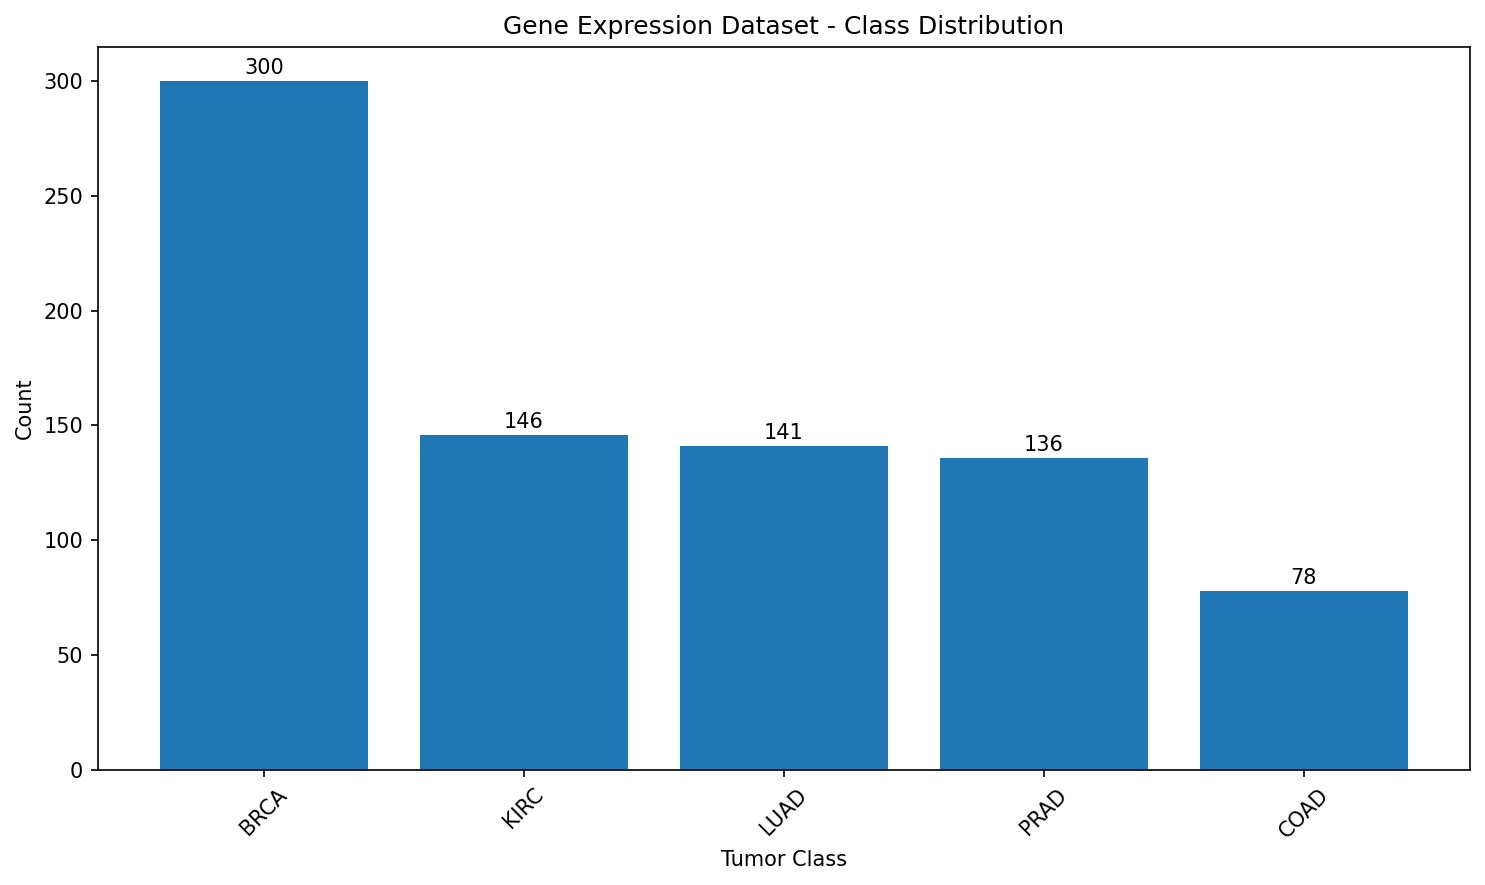

Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_05_PCA_Dimensionsreduktion\output\figures\phase3\day05_phase3_gene_class_distribution.png


In [7]:
# ============================================================
# Plot class distribution
# ============================================================

class_counts_sorted = y.value_counts().sort_values(ascending=False)

plt.figure(figsize=(10, 6), dpi=150)
plt.bar(class_counts_sorted.index, class_counts_sorted.values)

plt.title("Gene Expression Dataset - Class Distribution")
plt.xlabel("Tumor Class")
plt.ylabel("Count")
plt.xticks(rotation=45)

for i, value in enumerate(class_counts_sorted.values):
    plt.text(i, value + 3, str(value), ha="center")

plt.tight_layout()

class_plot_path = os.path.join(PHASE3_FIGURES_DIR, "day05_phase3_gene_class_distribution.png")
plt.savefig(class_plot_path, dpi=300)
plt.show()

print("Saved:", class_plot_path)

In [8]:
# ============================================================
# Standardization
# ============================================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("X_scaled shape:", X_scaled.shape)
print("Mean of first 5 scaled features:", np.round(X_scaled[:, :5].mean(axis=0), 4))
print("Std of first 5 scaled features :", np.round(X_scaled[:, :5].std(axis=0), 4))

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
class_names = label_encoder.classes_

print("Classes:", class_names)

X_scaled shape: (801, 20531)
Mean of first 5 scaled features: [-0. -0.  0.  0. -0.]
Std of first 5 scaled features : [1. 1. 1. 1. 1.]
Classes: ['BRCA' 'COAD' 'KIRC' 'LUAD' 'PRAD']


In [9]:
# ============================================================
# Optional speed mode
# ============================================================

# Full dataset has 801 samples, which is fine.
# If your laptop becomes slow, set USE_SUBSET = True.
USE_SUBSET = False
SUBSET_SIZE = 500

if USE_SUBSET and X_scaled.shape[0] > SUBSET_SIZE:
    rng = np.random.default_rng(42)
    subset_idx = rng.choice(X_scaled.shape[0], size=SUBSET_SIZE, replace=False)

    X_work = X_scaled[subset_idx]
    y_work = y.iloc[subset_idx].reset_index(drop=True)
    y_work_encoded = y_encoded[subset_idx]
    print("Using subset:", X_work.shape)
else:
    X_work = X_scaled
    y_work = y.reset_index(drop=True)
    y_work_encoded = y_encoded
    print("Using full dataset:", X_work.shape)

Using full dataset: (801, 20531)


## Part A — PCA 2D

PCA is a **linear** method. It is fast and useful as a baseline, but it may not separate nonlinear structures well.


In [10]:
# ============================================================
# PCA 2D with runtime measurement
# ============================================================

start_time = time.time()

pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_work)

time_pca = time.time() - start_time
trust_pca = trustworthiness(X_work, X_pca_2d, n_neighbors=15)

print("PCA 2D shape:", X_pca_2d.shape)
print("PCA runtime:", round(time_pca, 4), "seconds")
print("PCA trustworthiness:", round(trust_pca, 4))
print("PCA explained variance ratio:", pca_2d.explained_variance_ratio_)
print("PCA total explained variance:", pca_2d.explained_variance_ratio_.sum())

pca_df = pd.DataFrame({
    "Dim1": X_pca_2d[:, 0],
    "Dim2": X_pca_2d[:, 1],
    "tumor_class": y_work.values
})

pca_df.to_csv(os.path.join(PHASE3_TABLES_DIR, "day05_phase3_pca_2d_projection.csv"), index=False)

display(pca_df.head())

PCA 2D shape: (801, 2)
PCA runtime: 0.2417 seconds
PCA trustworthiness: 0.7863
PCA explained variance ratio: [0.10539781 0.08754232]
PCA total explained variance: 0.192940138199241


,Dim1,Dim2,tumor_class
0,-57.446987,-95.410982,PRAD
1,-16.919430,-0.732469,LUAD
2,-70.345218,19.303327,PRAD
3,-49.161591,9.227589,PRAD
4,-18.132534,51.327798,BRCA


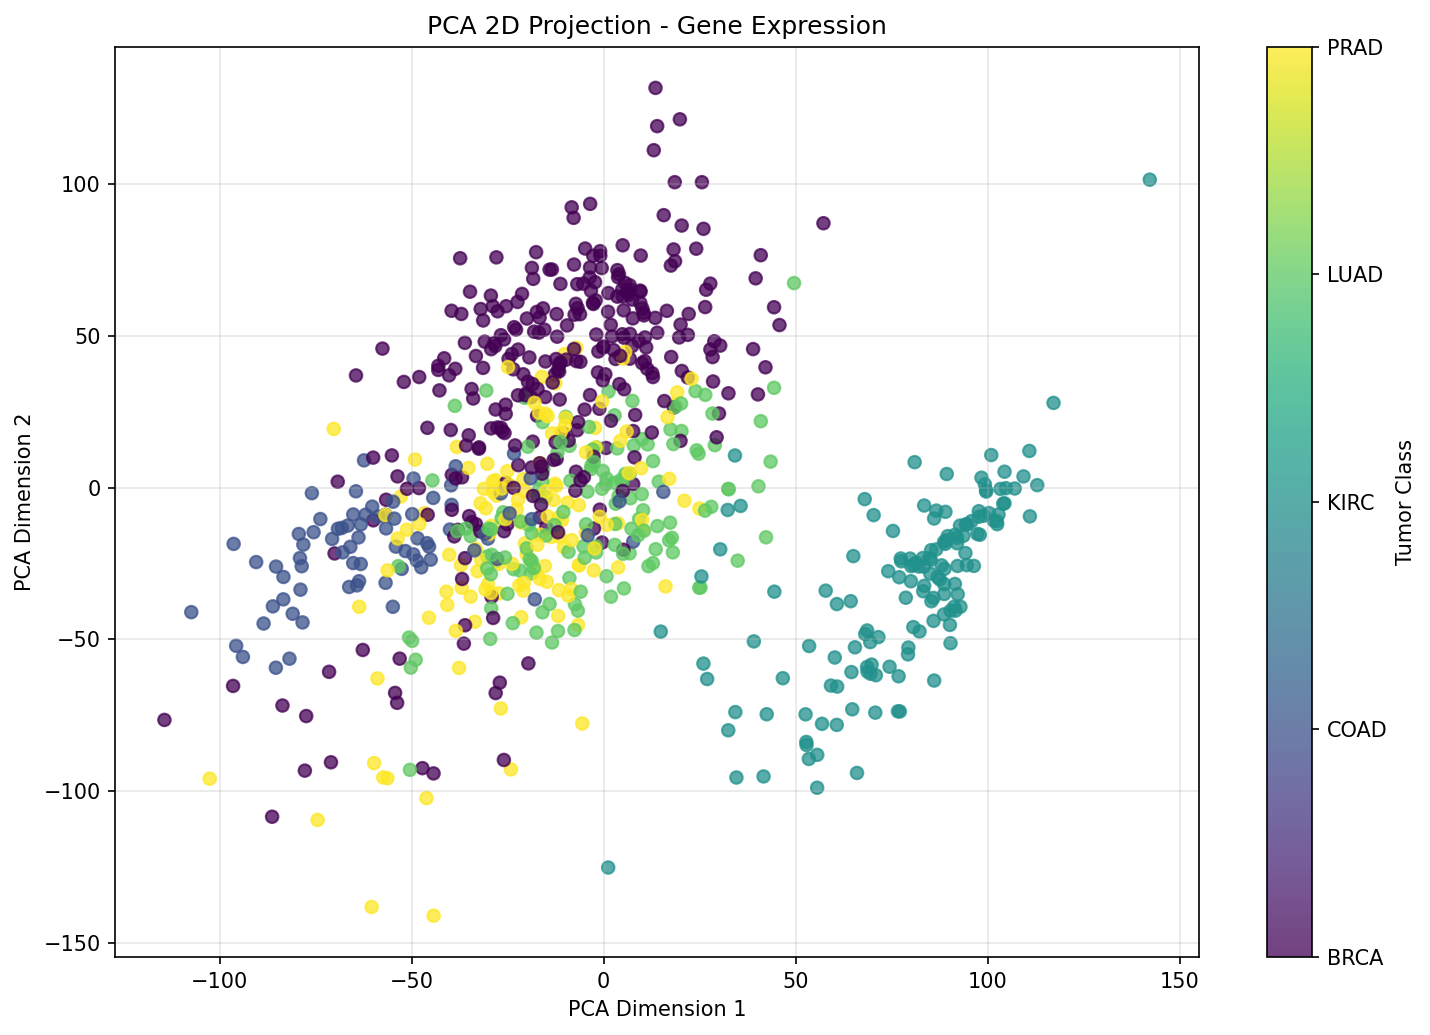

Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_05_PCA_Dimensionsreduktion\output\figures\phase3\day05_phase3_pca_2d_projection.png


In [11]:
# ============================================================
# Plot PCA 2D
# ============================================================

plt.figure(figsize=(10, 7), dpi=150)

scatter = plt.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=y_work_encoded,
    alpha=0.75
)

plt.title("PCA 2D Projection - Gene Expression")
plt.xlabel("PCA Dimension 1")
plt.ylabel("PCA Dimension 2")
plt.grid(True, alpha=0.3)

cbar = plt.colorbar(scatter, ticks=range(len(class_names)))
cbar.ax.set_yticklabels(class_names)
cbar.set_label("Tumor Class")

plt.tight_layout()

pca_plot_path = os.path.join(PHASE3_FIGURES_DIR, "day05_phase3_pca_2d_projection.png")
plt.savefig(pca_plot_path, dpi=300)
plt.show()

print("Saved:", pca_plot_path)

## Part B — t-SNE 2D

t-SNE is a nonlinear method that often separates clusters very clearly.  
It is usually slower than PCA and mainly used for visualization.


In [12]:
# ============================================================
# t-SNE 2D with runtime measurement
# ============================================================

start_time = time.time()

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

X_tsne_2d = tsne.fit_transform(X_work)

time_tsne = time.time() - start_time
trust_tsne = trustworthiness(X_work, X_tsne_2d, n_neighbors=15)

print("t-SNE 2D shape:", X_tsne_2d.shape)
print("t-SNE runtime:", round(time_tsne, 4), "seconds")
print("t-SNE trustworthiness:", round(trust_tsne, 4))

tsne_df = pd.DataFrame({
    "Dim1": X_tsne_2d[:, 0],
    "Dim2": X_tsne_2d[:, 1],
    "tumor_class": y_work.values
})

tsne_df.to_csv(os.path.join(PHASE3_TABLES_DIR, "day05_phase3_tsne_2d_projection.csv"), index=False)

display(tsne_df.head())

t-SNE 2D shape: (801, 2)
t-SNE runtime: 2.532 seconds
t-SNE trustworthiness: 0.9411


,Dim1,Dim2,tumor_class
0,0.140149,-19.649822,PRAD
1,-16.866146,3.776241,LUAD
2,-2.057563,-30.912773,PRAD
3,-1.462022,-26.756542,PRAD
4,7.635005,11.314794,BRCA


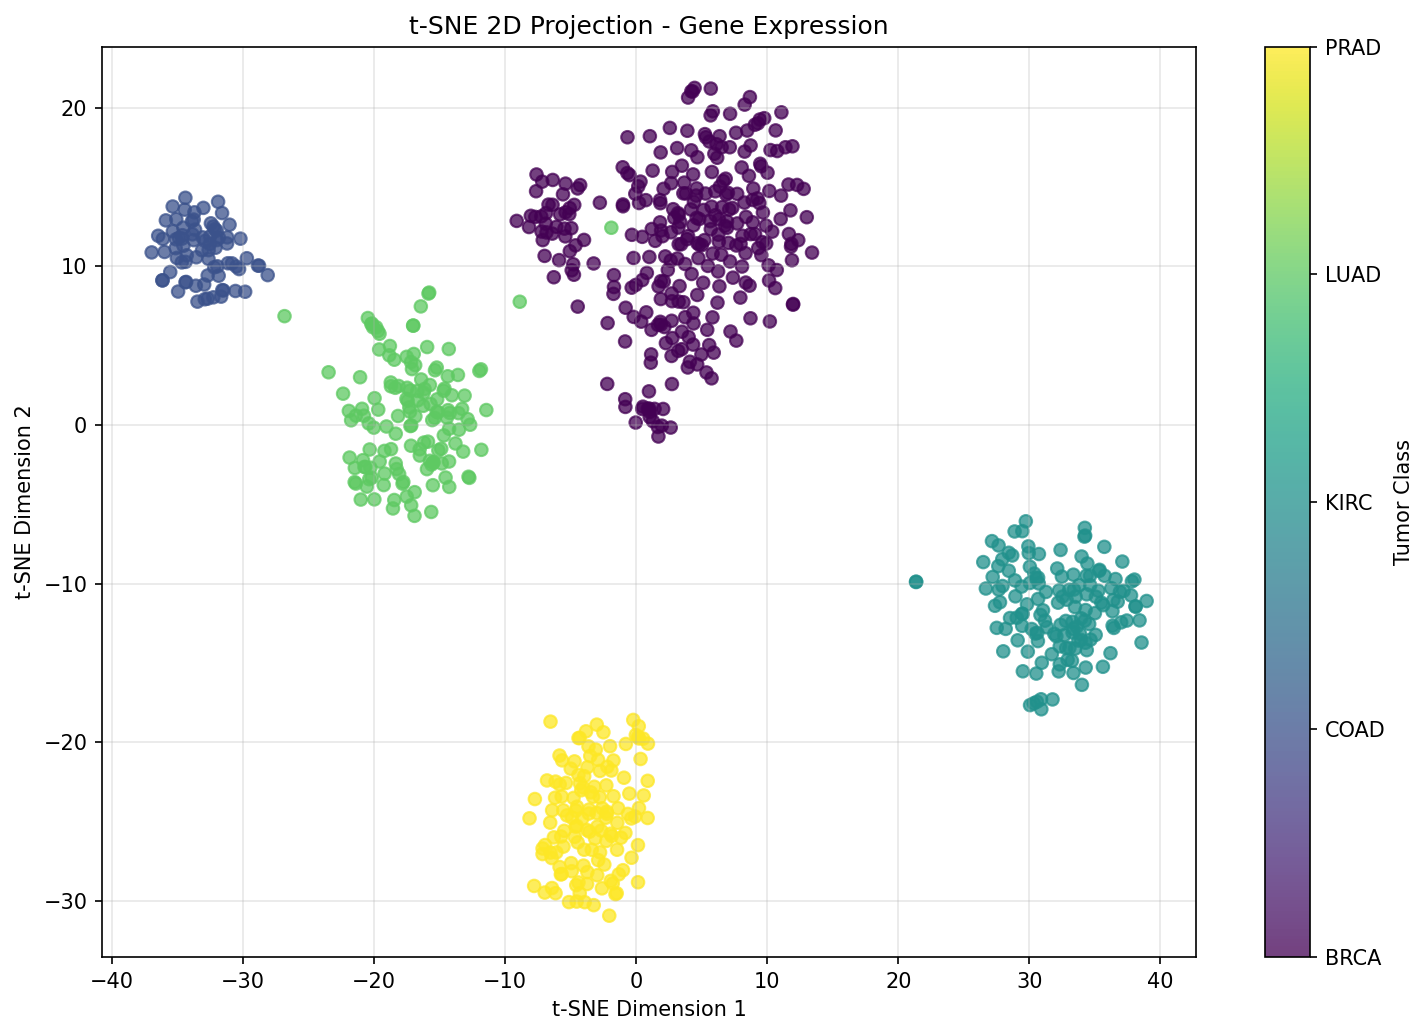

Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_05_PCA_Dimensionsreduktion\output\figures\phase3\day05_phase3_tsne_2d_projection.png


In [13]:
# ============================================================
# Plot t-SNE 2D
# ============================================================

plt.figure(figsize=(10, 7), dpi=150)

scatter = plt.scatter(
    X_tsne_2d[:, 0],
    X_tsne_2d[:, 1],
    c=y_work_encoded,
    alpha=0.75
)

plt.title("t-SNE 2D Projection - Gene Expression")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.grid(True, alpha=0.3)

cbar = plt.colorbar(scatter, ticks=range(len(class_names)))
cbar.ax.set_yticklabels(class_names)
cbar.set_label("Tumor Class")

plt.tight_layout()

tsne_plot_path = os.path.join(PHASE3_FIGURES_DIR, "day05_phase3_tsne_2d_projection.png")
plt.savefig(tsne_plot_path, dpi=300)
plt.show()

print("Saved:", tsne_plot_path)

## Part C — UMAP 2D

UMAP is also nonlinear. It often preserves local structure well and can be faster than t-SNE on larger datasets.


In [14]:
# ============================================================
# UMAP 2D with runtime measurement
# ============================================================

if not UMAP_AVAILABLE:
    raise ImportError("UMAP is not installed. Please run: pip install umap-learn")

start_time = time.time()

umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=42
)

X_umap_2d = umap_model.fit_transform(X_work)

time_umap = time.time() - start_time
trust_umap = trustworthiness(X_work, X_umap_2d, n_neighbors=15)

print("UMAP 2D shape:", X_umap_2d.shape)
print("UMAP runtime:", round(time_umap, 4), "seconds")
print("UMAP trustworthiness:", round(trust_umap, 4))

umap_df = pd.DataFrame({
    "Dim1": X_umap_2d[:, 0],
    "Dim2": X_umap_2d[:, 1],
    "tumor_class": y_work.values
})

umap_df.to_csv(os.path.join(PHASE3_TABLES_DIR, "day05_phase3_umap_2d_projection.csv"), index=False)

display(umap_df.head())

UMAP 2D shape: (801, 2)
UMAP runtime: 10.6983 seconds
UMAP trustworthiness: 0.9172


,Dim1,Dim2,tumor_class
0,1.572401,13.363288,PRAD
1,3.566338,-2.203867,LUAD
2,2.246238,15.079803,PRAD
3,1.911427,14.606858,PRAD
4,0.205343,5.717076,BRCA


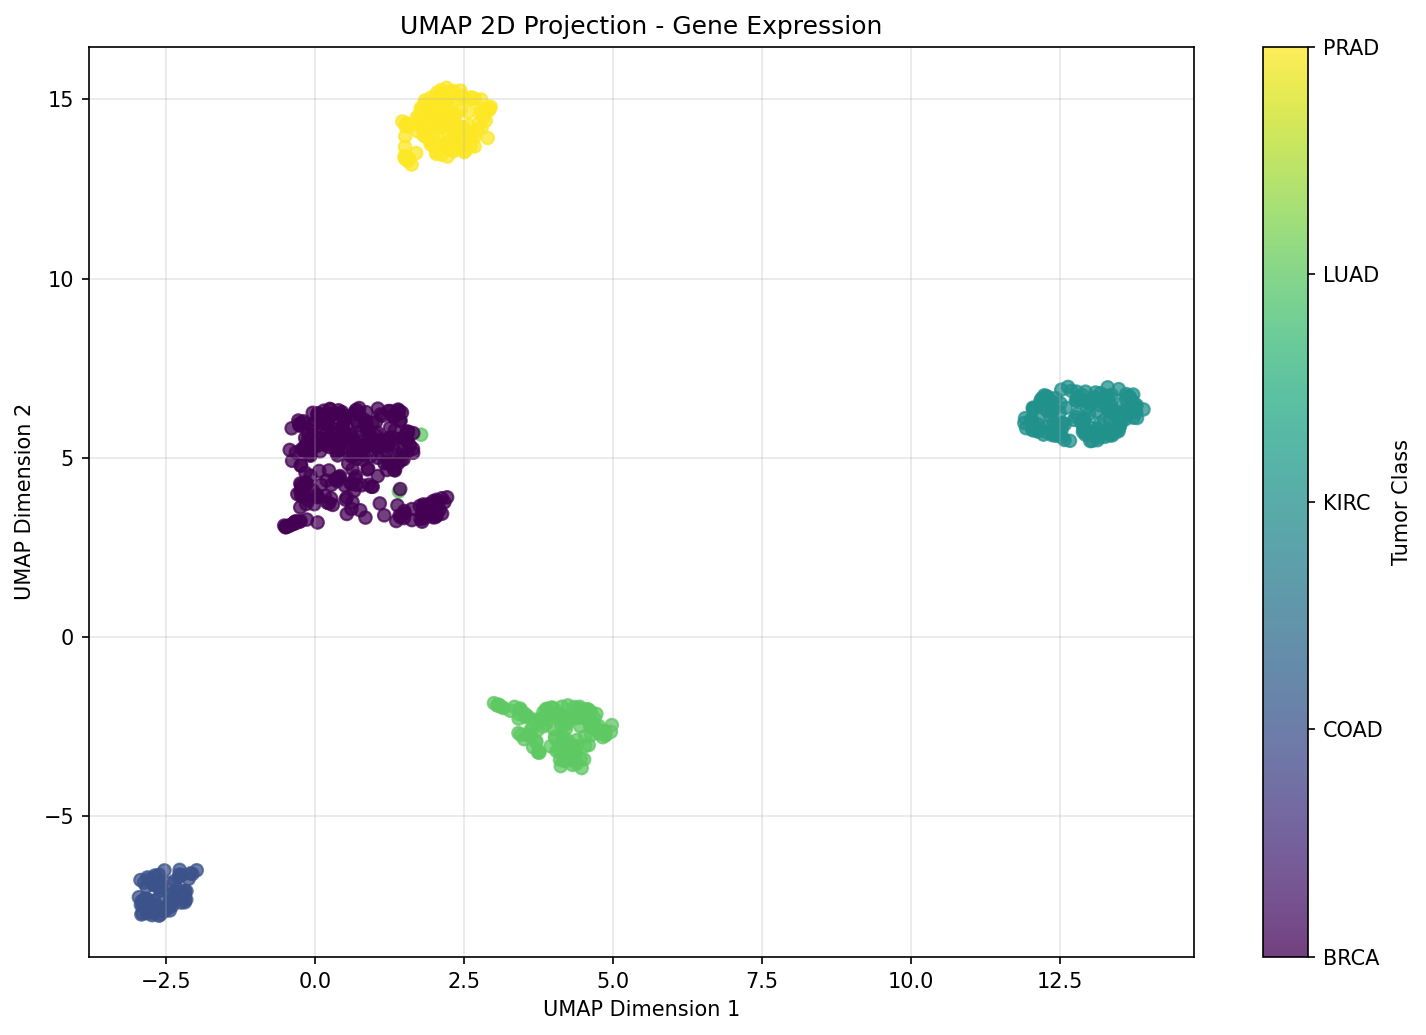

Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_05_PCA_Dimensionsreduktion\output\figures\phase3\day05_phase3_umap_2d_projection.png


In [15]:
# ============================================================
# Plot UMAP 2D
# ============================================================

plt.figure(figsize=(10, 7), dpi=150)

scatter = plt.scatter(
    X_umap_2d[:, 0],
    X_umap_2d[:, 1],
    c=y_work_encoded,
    alpha=0.75
)

plt.title("UMAP 2D Projection - Gene Expression")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.grid(True, alpha=0.3)

cbar = plt.colorbar(scatter, ticks=range(len(class_names)))
cbar.ax.set_yticklabels(class_names)
cbar.set_label("Tumor Class")

plt.tight_layout()

umap_plot_path = os.path.join(PHASE3_FIGURES_DIR, "day05_phase3_umap_2d_projection.png")
plt.savefig(umap_plot_path, dpi=300)
plt.show()

print("Saved:", umap_plot_path)

## Part D — Side-by-side comparison

This plot directly compares PCA, t-SNE, and UMAP on the same dataset.


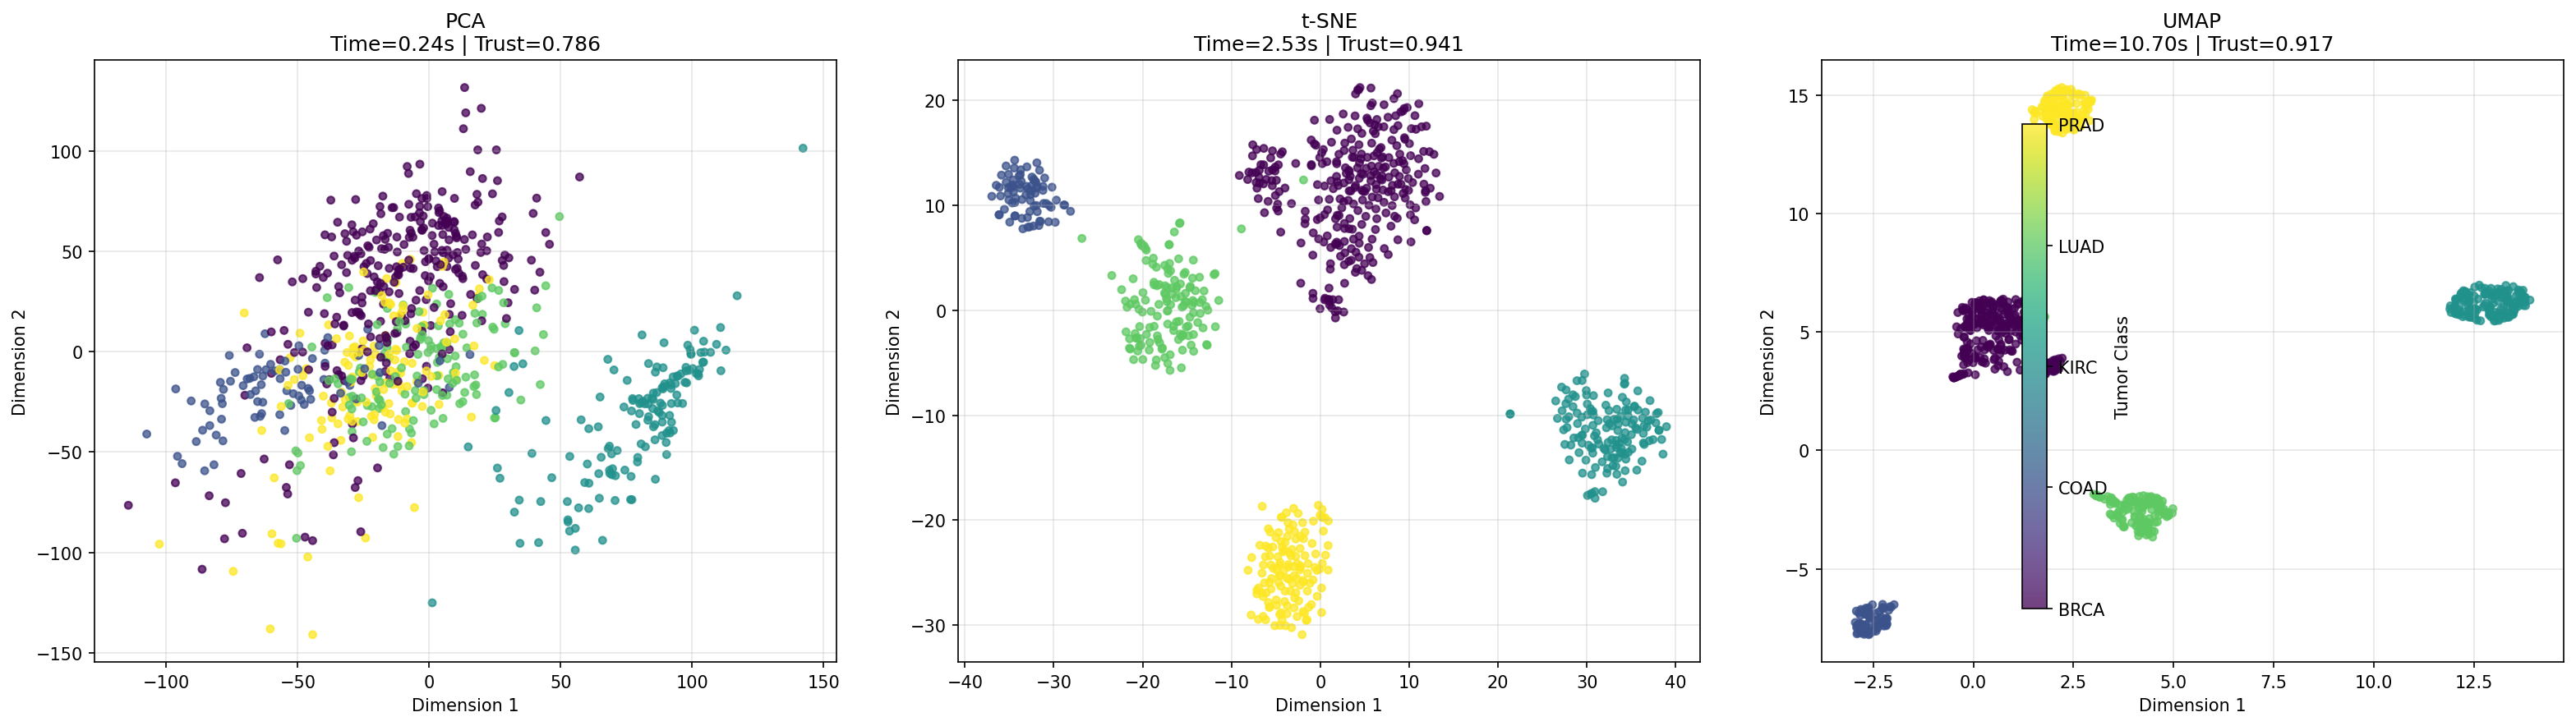

Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_05_PCA_Dimensionsreduktion\output\figures\phase3\day05_phase3_pca_tsne_umap_comparison.png


In [16]:
# ============================================================
# Side-by-side comparison plot
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(21, 6), dpi=150)

methods = [
    ("PCA", X_pca_2d, time_pca, trust_pca),
    ("t-SNE", X_tsne_2d, time_tsne, trust_tsne),
    ("UMAP", X_umap_2d, time_umap, trust_umap)
]

for ax, (name, X_proj, runtime, trust) in zip(axes, methods):
    sc = ax.scatter(
        X_proj[:, 0],
        X_proj[:, 1],
        c=y_work_encoded,
        alpha=0.75,
        s=18
    )
    ax.set_title(f"{name}\nTime={runtime:.2f}s | Trust={trust:.3f}")
    ax.set_xlabel("Dimension 1")
    ax.set_ylabel("Dimension 2")
    ax.grid(True, alpha=0.3)

cbar = fig.colorbar(sc, ax=axes, ticks=range(len(class_names)), shrink=0.85)
cbar.ax.set_yticklabels(class_names)
cbar.set_label("Tumor Class")

plt.tight_layout()

comparison_plot_path = os.path.join(PHASE3_FIGURES_DIR, "day05_phase3_pca_tsne_umap_comparison.png")
plt.savefig(comparison_plot_path, dpi=300)
plt.show()

print("Saved:", comparison_plot_path)

In [17]:
# ============================================================
# Runtime and Trustworthiness Comparison Table
# ============================================================

comparison_df = pd.DataFrame({
    "method": ["PCA", "t-SNE", "UMAP"],
    "runtime_seconds": [time_pca, time_tsne, time_umap],
    "trustworthiness": [trust_pca, trust_tsne, trust_umap],
    "notes": [
        "Linear baseline; fastest but may overlap clusters",
        "Nonlinear; often strong cluster visualization",
        "Nonlinear; often strong local structure preservation"
    ]
})

comparison_df["runtime_seconds"] = comparison_df["runtime_seconds"].round(4)
comparison_df["trustworthiness"] = comparison_df["trustworthiness"].round(4)

display(comparison_df)

comparison_path = os.path.join(PHASE3_TABLES_DIR, "day05_phase3_runtime_trustworthiness_comparison.csv")
comparison_df.to_csv(comparison_path, index=False)

print("Saved:", comparison_path)

,method,runtime_seconds,trustworthiness,notes
0,PCA,0.2417,0.7863,Linear baseline; fastest but may overlap clusters
1,t-SNE,2.5320,0.9411,Nonlinear; often strong cluster visualization
2,UMAP,10.6983,0.9172,Nonlinear; often strong local structure preser...


Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_05_PCA_Dimensionsreduktion\output\tables\phase3\day05_phase3_runtime_trustworthiness_comparison.csv


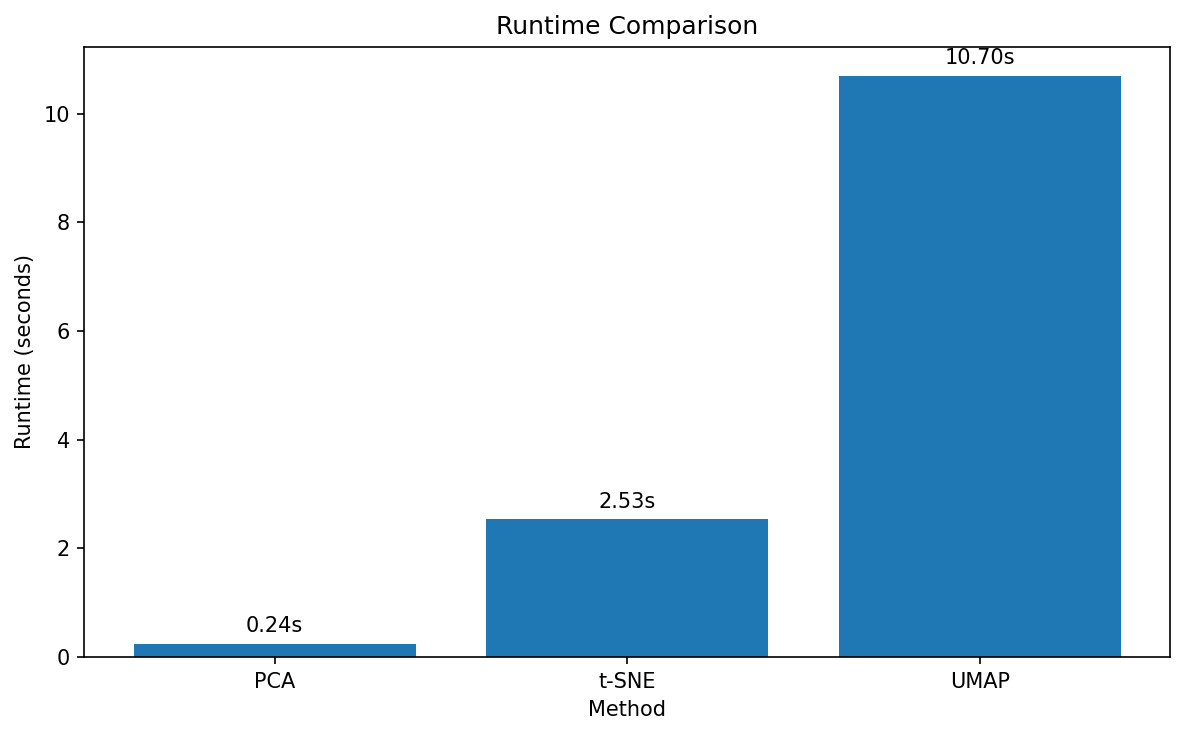

Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_05_PCA_Dimensionsreduktion\output\figures\phase3\day05_phase3_runtime_comparison.png


In [18]:
# ============================================================
# Plot runtime comparison
# ============================================================

plt.figure(figsize=(8, 5), dpi=150)

plt.bar(comparison_df["method"], comparison_df["runtime_seconds"])

plt.title("Runtime Comparison")
plt.xlabel("Method")
plt.ylabel("Runtime (seconds)")

for i, value in enumerate(comparison_df["runtime_seconds"]):
    plt.text(i, value + max(comparison_df["runtime_seconds"]) * 0.02, f"{value:.2f}s", ha="center")

plt.tight_layout()

runtime_plot_path = os.path.join(PHASE3_FIGURES_DIR, "day05_phase3_runtime_comparison.png")
plt.savefig(runtime_plot_path, dpi=300)
plt.show()

print("Saved:", runtime_plot_path)

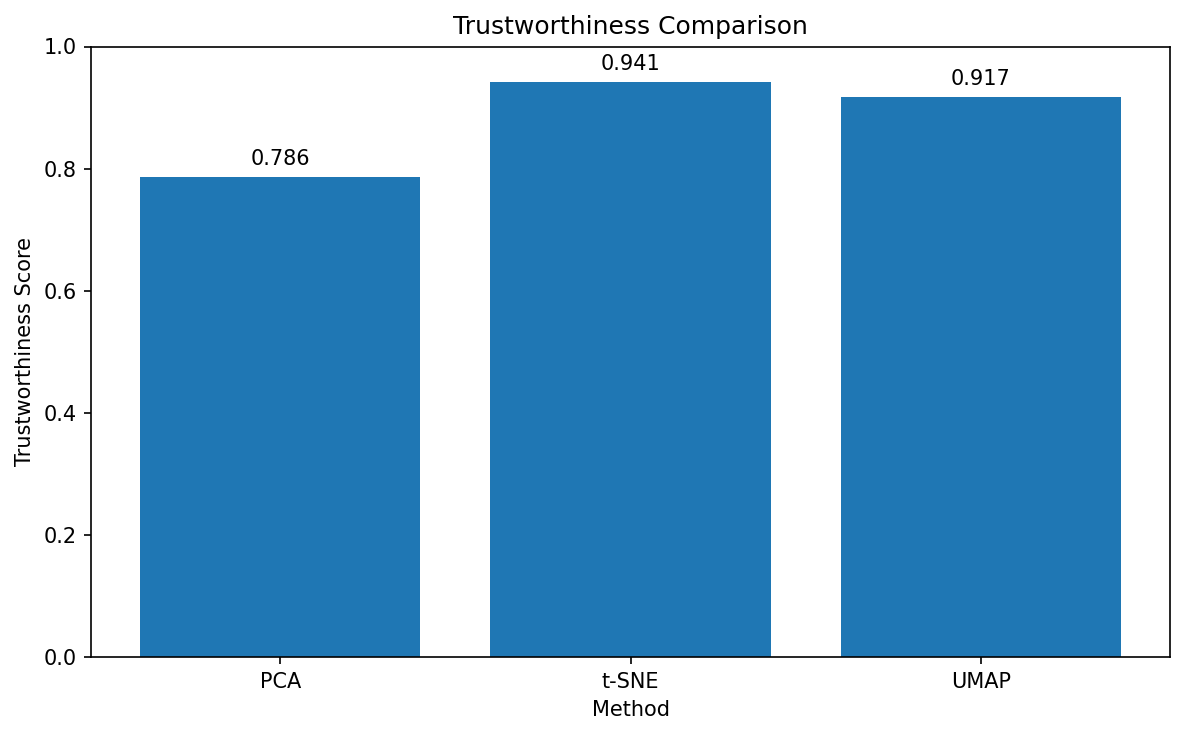

Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_05_PCA_Dimensionsreduktion\output\figures\phase3\day05_phase3_trustworthiness_comparison.png


In [19]:
# ============================================================
# Plot trustworthiness comparison
# ============================================================

plt.figure(figsize=(8, 5), dpi=150)

plt.bar(comparison_df["method"], comparison_df["trustworthiness"])

plt.title("Trustworthiness Comparison")
plt.xlabel("Method")
plt.ylabel("Trustworthiness Score")
plt.ylim(0, 1)

for i, value in enumerate(comparison_df["trustworthiness"]):
    plt.text(i, value + 0.02, f"{value:.3f}", ha="center")

plt.tight_layout()

trust_plot_path = os.path.join(PHASE3_FIGURES_DIR, "day05_phase3_trustworthiness_comparison.png")
plt.savefig(trust_plot_path, dpi=300)
plt.show()

print("Saved:", trust_plot_path)

## Part E — PCA(50) + UMAP trick

Instead of running UMAP directly on all 20,000+ gene features, we first reduce the data to 50 PCA components, then run UMAP on those 50 components.


In [20]:
# ============================================================
# PCA(50) + UMAP
# ============================================================

if not UMAP_AVAILABLE:
    raise ImportError("UMAP is not installed. Please run: pip install umap-learn")

start_time = time.time()

pca_50 = PCA(n_components=50, random_state=42)
X_pca_50 = pca_50.fit_transform(X_work)

umap_after_pca = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=42
)

X_pca50_umap_2d = umap_after_pca.fit_transform(X_pca_50)

time_pca50_umap = time.time() - start_time

trust_pca50_umap_original = trustworthiness(X_work, X_pca50_umap_2d, n_neighbors=15)
trust_pca50_umap_pca50 = trustworthiness(X_pca_50, X_pca50_umap_2d, n_neighbors=15)

print("PCA(50) + UMAP shape:", X_pca50_umap_2d.shape)
print("PCA(50) + UMAP runtime:", round(time_pca50_umap, 4), "seconds")
print("Trustworthiness vs original X:", round(trust_pca50_umap_original, 4))
print("Trustworthiness vs PCA50 X:", round(trust_pca50_umap_pca50, 4))
print("PCA50 explained variance:", round(pca_50.explained_variance_ratio_.sum(), 4))

pca50_umap_df = pd.DataFrame({
    "Dim1": X_pca50_umap_2d[:, 0],
    "Dim2": X_pca50_umap_2d[:, 1],
    "tumor_class": y_work.values
})

pca50_umap_df.to_csv(os.path.join(PHASE3_TABLES_DIR, "day05_phase3_pca50_umap_2d_projection.csv"), index=False)

display(pca50_umap_df.head())

PCA(50) + UMAP shape: (801, 2)
PCA(50) + UMAP runtime: 1.7214 seconds
Trustworthiness vs original X: 0.9318
Trustworthiness vs PCA50 X: 0.9614
PCA50 explained variance: 0.6367


,Dim1,Dim2,tumor_class
0,12.777489,-6.977105,PRAD
1,-0.581748,9.231385,LUAD
2,12.455674,-5.417400,PRAD
3,12.469497,-5.428615,PRAD
4,10.736697,4.905422,BRCA


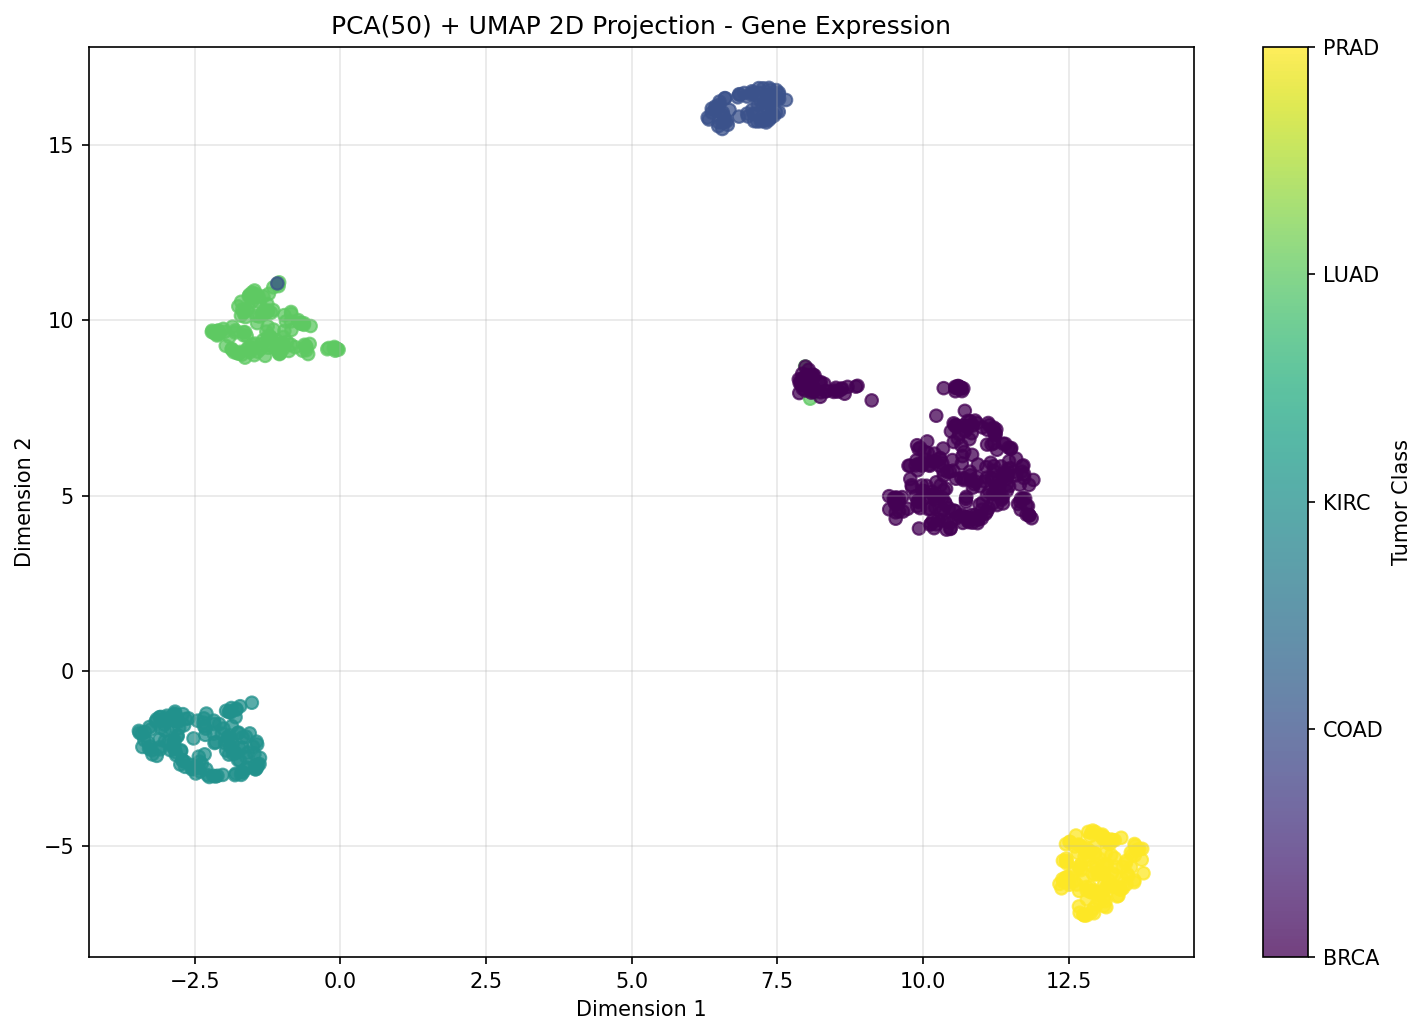

Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_05_PCA_Dimensionsreduktion\output\figures\phase3\day05_phase3_pca50_umap_2d_projection.png


In [21]:
# ============================================================
# Plot PCA(50) + UMAP
# ============================================================

plt.figure(figsize=(10, 7), dpi=150)

scatter = plt.scatter(
    X_pca50_umap_2d[:, 0],
    X_pca50_umap_2d[:, 1],
    c=y_work_encoded,
    alpha=0.75
)

plt.title("PCA(50) + UMAP 2D Projection - Gene Expression")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.grid(True, alpha=0.3)

cbar = plt.colorbar(scatter, ticks=range(len(class_names)))
cbar.ax.set_yticklabels(class_names)
cbar.set_label("Tumor Class")

plt.tight_layout()

pca50_umap_plot_path = os.path.join(PHASE3_FIGURES_DIR, "day05_phase3_pca50_umap_2d_projection.png")
plt.savefig(pca50_umap_plot_path, dpi=300)
plt.show()

print("Saved:", pca50_umap_plot_path)

In [22]:
# ============================================================
# Compare Direct UMAP vs PCA(50) + UMAP
# ============================================================

umap_comparison_df = pd.DataFrame({
    "method": ["Direct UMAP", "PCA(50) + UMAP"],
    "runtime_seconds": [time_umap, time_pca50_umap],
    "trustworthiness_vs_original": [trust_umap, trust_pca50_umap_original],
    "trustworthiness_vs_input_space": [trust_umap, trust_pca50_umap_pca50],
    "input_dimensions": [X_work.shape[1], 50],
    "notes": [
        "UMAP directly on all standardized gene features",
        "PCA first reduces to 50 components, then UMAP runs on PCA space"
    ]
})

umap_comparison_df["runtime_seconds"] = umap_comparison_df["runtime_seconds"].round(4)
umap_comparison_df["trustworthiness_vs_original"] = umap_comparison_df["trustworthiness_vs_original"].round(4)
umap_comparison_df["trustworthiness_vs_input_space"] = umap_comparison_df["trustworthiness_vs_input_space"].round(4)

display(umap_comparison_df)

umap_comparison_path = os.path.join(PHASE3_TABLES_DIR, "day05_phase3_direct_umap_vs_pca50_umap.csv")
umap_comparison_df.to_csv(umap_comparison_path, index=False)

print("Saved:", umap_comparison_path)

,method,runtime_seconds,trustworthiness_vs_original,trustworthiness_vs_input_space,input_dimensions,notes
0,Direct UMAP,10.6983,0.9172,0.9172,20531,UMAP directly on all standardized gene features
1,PCA(50) + UMAP,1.7214,0.9318,0.9614,50,"PCA first reduces to 50 components, then UMAP ..."


Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_05_PCA_Dimensionsreduktion\output\tables\phase3\day05_phase3_direct_umap_vs_pca50_umap.csv


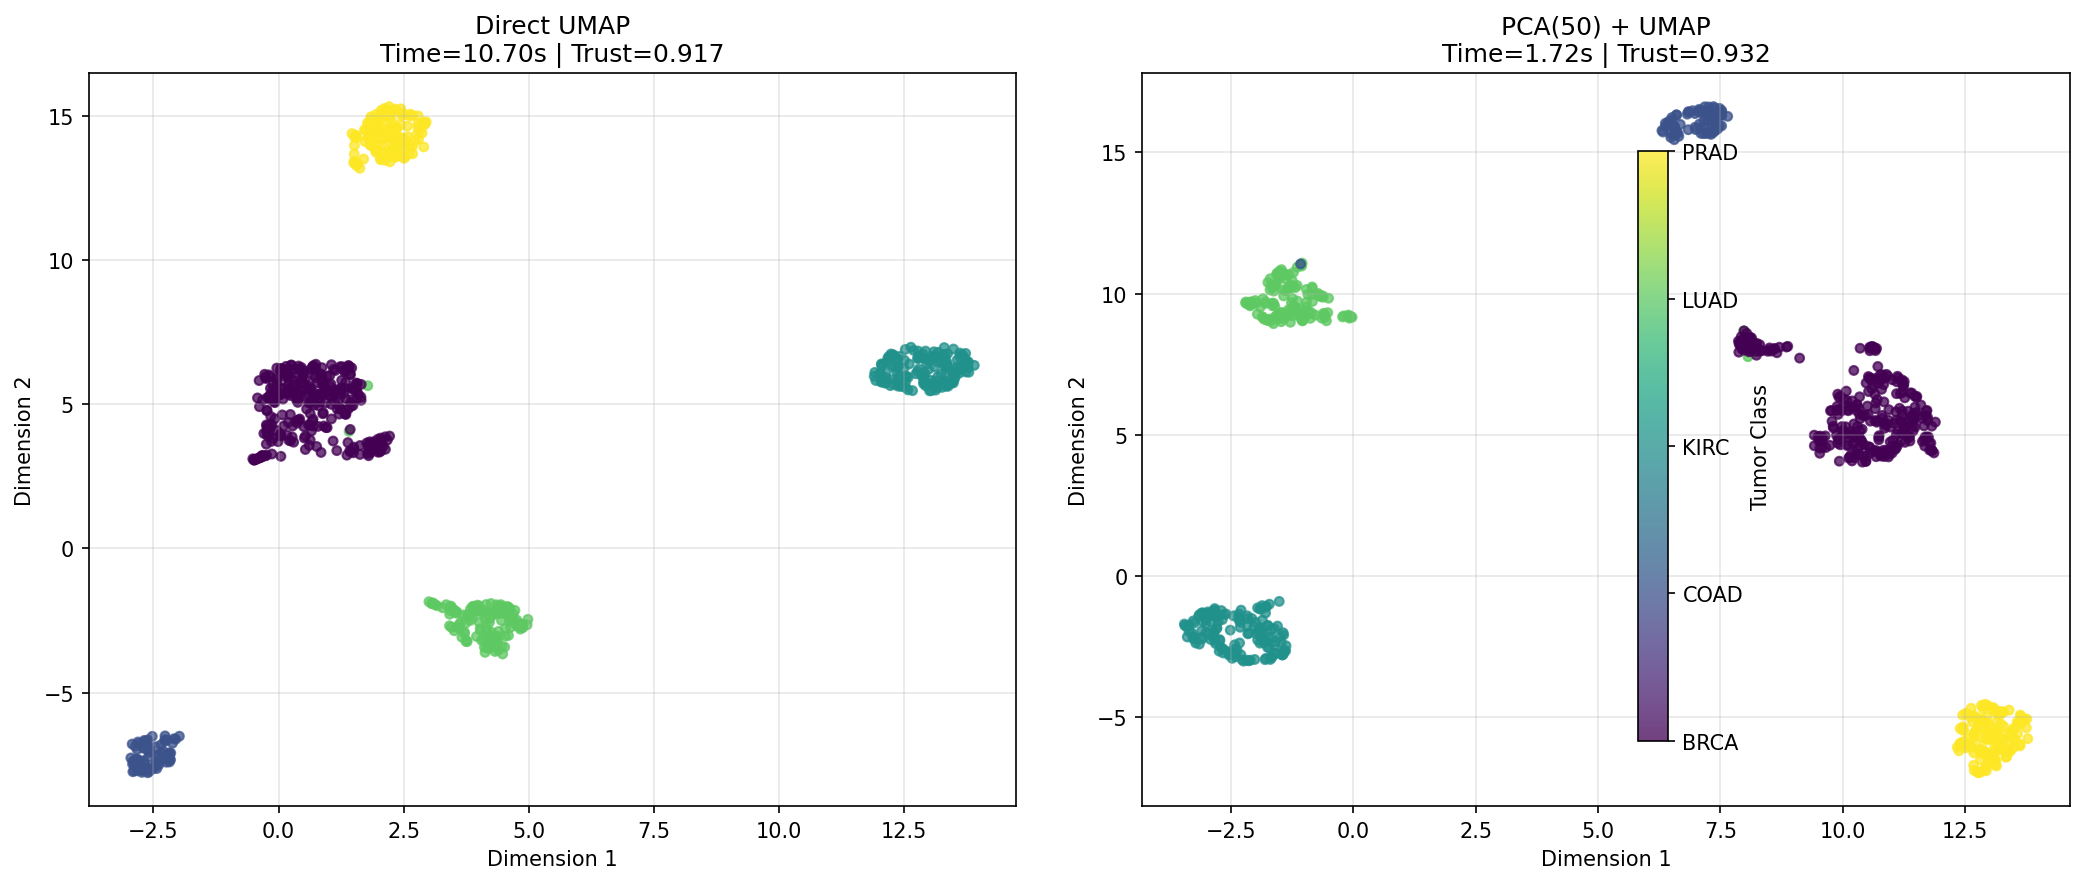

Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_05_PCA_Dimensionsreduktion\output\figures\phase3\day05_phase3_direct_umap_vs_pca50_umap.png


In [23]:
# ============================================================
# Side-by-side Direct UMAP vs PCA(50) + UMAP
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=150)

umap_methods = [
    ("Direct UMAP", X_umap_2d, time_umap, trust_umap),
    ("PCA(50) + UMAP", X_pca50_umap_2d, time_pca50_umap, trust_pca50_umap_original)
]

for ax, (name, X_proj, runtime, trust) in zip(axes, umap_methods):
    sc = ax.scatter(
        X_proj[:, 0],
        X_proj[:, 1],
        c=y_work_encoded,
        alpha=0.75,
        s=18
    )
    ax.set_title(f"{name}\nTime={runtime:.2f}s | Trust={trust:.3f}")
    ax.set_xlabel("Dimension 1")
    ax.set_ylabel("Dimension 2")
    ax.grid(True, alpha=0.3)

cbar = fig.colorbar(sc, ax=axes, ticks=range(len(class_names)), shrink=0.85)
cbar.ax.set_yticklabels(class_names)
cbar.set_label("Tumor Class")

plt.tight_layout()

umap_comparison_plot_path = os.path.join(PHASE3_FIGURES_DIR, "day05_phase3_direct_umap_vs_pca50_umap.png")
plt.savefig(umap_comparison_plot_path, dpi=300)
plt.show()

print("Saved:", umap_comparison_plot_path)

In [24]:
# ============================================================
# Automatic Summary
# ============================================================

best_trust_method = comparison_df.sort_values("trustworthiness", ascending=False).iloc[0]["method"]
fastest_method = comparison_df.sort_values("runtime_seconds", ascending=True).iloc[0]["method"]

summary = {
    "Number of samples": X_work.shape[0],
    "Number of original gene features": X_work.shape[1],
    "Number of tumor classes": len(class_names),
    "PCA runtime seconds": round(time_pca, 4),
    "t-SNE runtime seconds": round(time_tsne, 4),
    "UMAP runtime seconds": round(time_umap, 4),
    "PCA trustworthiness": round(trust_pca, 4),
    "t-SNE trustworthiness": round(trust_tsne, 4),
    "UMAP trustworthiness": round(trust_umap, 4),
    "Fastest method": fastest_method,
    "Best trustworthiness method": best_trust_method,
    "PCA50 explained variance": round(pca_50.explained_variance_ratio_.sum(), 4),
    "PCA50 + UMAP runtime seconds": round(time_pca50_umap, 4),
    "PCA50 + UMAP trustworthiness vs original": round(trust_pca50_umap_original, 4)
}

summary_df = pd.DataFrame(list(summary.items()), columns=["item", "value"])
display(summary_df)

summary_path = os.path.join(PHASE3_TABLES_DIR, "day05_phase3_summary.csv")
summary_df.to_csv(summary_path, index=False)

print("Saved:", summary_path)

,item,value
0,Number of samples,801
1,Number of original gene features,20531
2,Number of tumor classes,5
3,PCA runtime seconds,0.2417
4,t-SNE runtime seconds,2.532
5,UMAP runtime seconds,10.6983
6,PCA trustworthiness,0.7863
7,t-SNE trustworthiness,0.9411
8,UMAP trustworthiness,0.9172
9,Fastest method,PCA


Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_05_PCA_Dimensionsreduktion\output\tables\phase3\day05_phase3_summary.csv


In [25]:
# ============================================================
# Final Check: List created output files
# ============================================================

print("✅ Files created in PHASE3_TABLES_DIR:")
for file in os.listdir(PHASE3_TABLES_DIR):
    print(" -", file)

print("\n✅ Files created in PHASE3_FIGURES_DIR:")
for file in os.listdir(PHASE3_FIGURES_DIR):
    print(" -", file)

✅ Files created in PHASE3_TABLES_DIR:
 - day05_phase3_basic_info.csv
 - day05_phase3_class_counts.csv
 - day05_phase3_direct_umap_vs_pca50_umap.csv
 - day05_phase3_pca50_umap_2d_projection.csv
 - day05_phase3_pca_2d_projection.csv
 - day05_phase3_runtime_trustworthiness_comparison.csv
 - day05_phase3_summary.csv
 - day05_phase3_tsne_2d_projection.csv
 - day05_phase3_umap_2d_projection.csv

✅ Files created in PHASE3_FIGURES_DIR:
 - day05_phase3_direct_umap_vs_pca50_umap.png
 - day05_phase3_gene_class_distribution.png
 - day05_phase3_pca50_umap_2d_projection.png
 - day05_phase3_pca_2d_projection.png
 - day05_phase3_pca_tsne_umap_comparison.png
 - day05_phase3_runtime_comparison.png
 - day05_phase3_trustworthiness_comparison.png
 - day05_phase3_tsne_2d_projection.png
 - day05_phase3_umap_2d_projection.png


# What to send back for analysis

Please upload these files after running the notebook:

## Tables

- `output/tables/phase3/day05_phase3_runtime_trustworthiness_comparison.csv`
- `output/tables/phase3/day05_phase3_direct_umap_vs_pca50_umap.csv`
- `output/tables/phase3/day05_phase3_summary.csv`

## Figures

- `output/figures/phase3/day05_phase3_pca_tsne_umap_comparison.png`
- `output/figures/phase3/day05_phase3_runtime_comparison.png`
- `output/figures/phase3/day05_phase3_trustworthiness_comparison.png`
- `output/figures/phase3/day05_phase3_direct_umap_vs_pca50_umap.png`

Then we will create the final Phase 3 PDF report with code explanation, chart analysis, terminology, and German/Persian conclusions.
